In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BSpline

In [6]:
def plot_bspline_basis(k, n_basis, ax):
    knots = np.concatenate((
        np.zeros(k),
        np.linspace(0, 1, n_basis - k + 1),
        np.ones(k)
    ))

    x_vals = np.linspace(0, 1, 500)
    colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown']

    for i in range(n_basis):
        coeffs = np.zeros(n_basis)
        coeffs[i] = 1
        basis = BSpline(knots, coeffs, k)
        y_vals = basis(x_vals)
        ax.plot(x_vals, y_vals, label=rf'$N_{{{i},{k}}}$', color=colors[i % len(colors)])

    ax.set_title(rf'Degree $k={k}$')
    ax.set_ylim(0, 1.2)
    ax.grid(True)
    ax.set_xlabel('x')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right', fontsize=8)

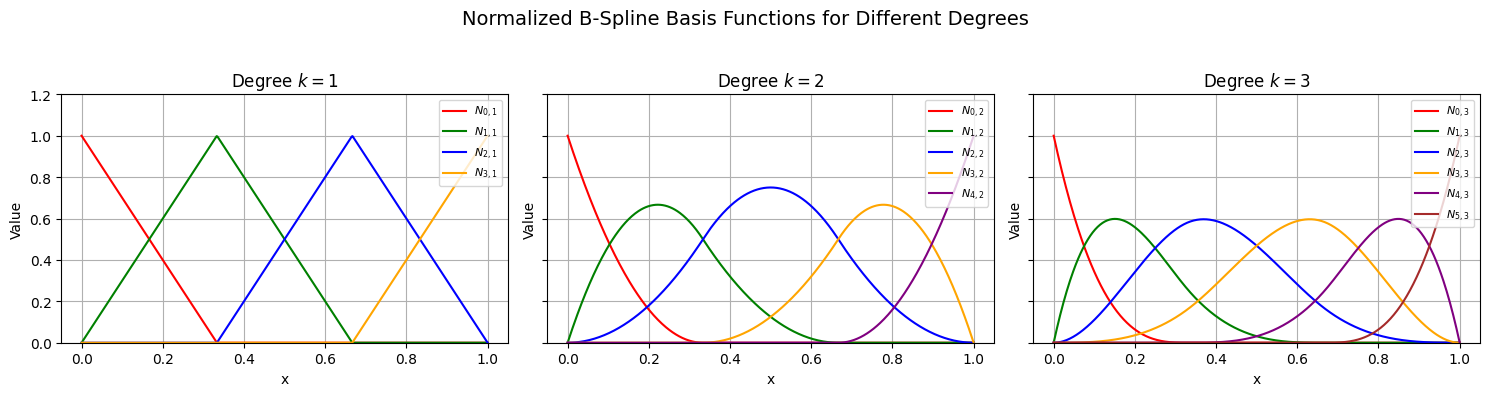

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx, k in enumerate([1, 2, 3]):
    n_basis = k + 3
    plot_bspline_basis(k, n_basis, axes[idx])

plt.suptitle('Normalized B-Spline Basis Functions for Different Degrees', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()